<a href="https://colab.research.google.com/github/waelyounes/quantitative-portfolio-optimization/blob/main/portfolio_optimization_quant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔄 Fetching data for tickers: ['AAPL', 'MSFT', 'GOOGL', 'TSLA']...


/tmp/ipykernel_1322/3512727157.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)["Close"]
[*********************100%***********************]  4 of 4 completed


/tmp/ipykernel_1322/3512727157.py:107: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


🎯 Optimal Asset Weights (Max Sharpe Ratio):
  - AAPL: 15.76%
  - MSFT: 2.54%
  - GOOGL: 80.96%
  - TSLA: 0.73%

🔄 Running Backtest for AAPL...
📊 Backtesting Performance for AAPL:
----------------------------------------
🔹 Buy & Hold Return : 6.99%
🔹 Strategy Return   : -7.59%
🔹 Maximum Drawdown  : -29.03%


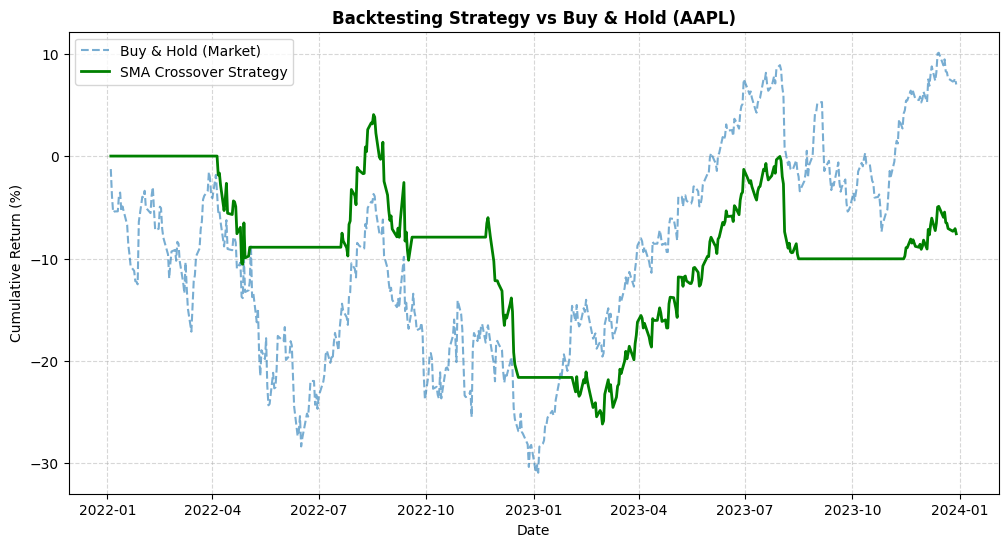

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import yfinance as yf


# ==============================================================================
# PART 1: Interactive Portfolio Analysis & Monte Carlo Simulation Dashboard
# ==============================================================================
def complete_portfolio_dashboard(
    tickers, start_date, end_date, num_portfolios=5000, risk_free_rate=0.04
):
  """Comprehensive Quant Pipeline: Data Fetching, Interactive Plots, and Monte Carlo Portfolio Optimization."""
  print(f"🔄 Fetching data for tickers: {tickers}...")
  # 1. Fetch Data
  data = yf.download(tickers, start=start_date, end=end_date)["Close"]
  daily_returns = data.pct_change().dropna()

  # 2. Cumulative Returns Plot
  cum_returns = (1 + daily_returns).cumprod() - 1
  fig_cum = px.line(
      cum_returns * 100,
      title="📈 Interactive Cumulative Returns (%)",
      labels={"value": "Return (%)", "Date": "Date", "variable": "Ticker"},
  )
  fig_cum.update_layout(hovermode="x unified", template="plotly_white")
  fig_cum.show()

  # 3. Correlation Heatmap
  corr_matrix = daily_returns.corr()
  fig_corr = px.imshow(
      corr_matrix.round(2),
      text_auto=True,
      color_continuous_scale="Blues",
      title="🔥 Interactive Correlation Heatmap",
  )
  fig_corr.show()

  # 4. Monte Carlo Simulation
  mean_returns = daily_returns.mean() * 252
  cov_matrix = daily_returns.cov() * 252

  results = np.zeros((3 + len(tickers), num_portfolios))
  np.random.seed(42)

  for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    p_return = np.dot(weights, mean_returns)
    p_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    results[0, i] = p_return
    results[1, i] = p_volatility
    results[2, i] = (p_return - risk_free_rate) / p_volatility

    for j in range(len(weights)):
      results[3 + j, i] = weights[j]

  cols = ["Return", "Volatility", "Sharpe"] + tickers
  portfolios_df = pd.DataFrame(results.T, columns=cols)

  # Find Max Sharpe Ratio Portfolio
  max_sharpe = portfolios_df.iloc[portfolios_df["Sharpe"].idxmax()]

  # 5. Plot Efficient Frontier
  fig_ef = px.scatter(
      portfolios_df,
      x="Volatility",
      y="Return",
      color="Sharpe",
      title="🎯 Interactive Efficient Frontier & Monte Carlo Simulation",
      labels={"Volatility": "Annual Volatility", "Return": "Expected Return"},
      color_continuous_scale="Viridis",
  )

  # Highlight Max Sharpe Portfolio with Red Star
  fig_ef.add_trace(
      go.Scatter(
          x=[max_sharpe["Volatility"]],
          y=[max_sharpe["Return"]],
          mode="markers",
          marker=dict(color="red", size=15, symbol="star"),
          name="Max Sharpe Ratio",
      )
  )
  fig_ef.show()

  # Print Optimal Allocation Weights
  print("\n🎯 Optimal Asset Weights (Max Sharpe Ratio):")
  for ticker in tickers:
    print(f"  - {ticker}: {max_sharpe[ticker]*100:.2f}%")

  return portfolios_df


# ==============================================================================
# PART 2: Algorithmic Strategy Backtesting (SMA Crossover) & Risk Analysis
# ==============================================================================
def backtest_sma_strategy(ticker, start_date, end_date, fast_window=20, slow_window=50):
  """Backtests a Simple Moving Average (SMA) Crossover Strategy and computes Maximum Drawdown."""
  print(f"\n🔄 Running Backtest for {ticker}...")

  # 1. Fetch Single Stock Data
  data = yf.download(ticker, start=start_date, end=end_date)["Close"]
  df = pd.DataFrame(data)
  df.columns = ["Close"]

  # 2. Compute Indicators
  df["SMA_Fast"] = df["Close"].rolling(window=fast_window).mean()
  df["SMA_Slow"] = df["Close"].rolling(window=slow_window).mean()

  # 3. Generate Trading Signals cleanly using np.where and .loc
  df["Signal"] = np.where(df["SMA_Fast"] > df["SMA_Slow"], 1, 0)
  df.loc[: df.index[slow_window], "Signal"] = 0  # Clean warmup period
  df["Position"] = df["Signal"].diff()

  # 4. Calculate Returns (Shifted to avoid look-ahead bias)
  df["Daily_Return"] = df["Close"].pct_change()
  df["Strategy_Return"] = df["Daily_Return"] * df["Signal"].shift(1)

  df["Cum_Market"] = (1 + df["Daily_Return"]).cumprod() - 1
  df["Cum_Strategy"] = (1 + df["Strategy_Return"]).cumprod() - 1

  # 5. Compute Maximum Drawdown (Max DD)
  df["Strategy_Peak"] = (1 + df["Strategy_Return"]).cumprod().cummax()
  df["Drawdown"] = (
      (1 + df["Strategy_Return"]).cumprod() - df["Strategy_Peak"]
  ) / df["Strategy_Peak"]
  max_drawdown = df["Drawdown"].min()

  # 6. Performance Summary
  total_market = df["Cum_Market"].iloc[-1] * 100
  total_strategy = df["Cum_Strategy"].iloc[-1] * 100

  print(f"📊 Backtesting Performance for {ticker}:")
  print(f"----------------------------------------")
  print(f"🔹 Buy & Hold Return : {total_market:.2f}%")
  print(f"🔹 Strategy Return   : {total_strategy:.2f}%")
  print(f"🔹 Maximum Drawdown  : {max_drawdown * 100:.2f}%")

  # 7. Plot Strategy Performance
  plt.figure(figsize=(12, 6))
  plt.plot(
      df["Cum_Market"] * 100,
      label="Buy & Hold (Market)",
      alpha=0.6,
      linestyle="--",
  )
  plt.plot(
      df["Cum_Strategy"] * 100,
      label="SMA Crossover Strategy",
      color="green",
      linewidth=2,
  )
  plt.title(
      f"Backtesting Strategy vs Buy & Hold ({ticker})",
      fontsize=12,
      fontweight="bold",
  )
  plt.xlabel("Date")
  plt.ylabel("Cumulative Return (%)")
  plt.legend()
  plt.grid(True, linestyle="--", alpha=0.5)
  plt.show()


# ==============================================================================
# EXECUTION / DRIVER CODE
# ==============================================================================
if __name__ == "__main__":
  # Define Portfolio Stocks & Timeframe
  tickers_list = ["AAPL", "MSFT", "GOOGL", "TSLA"]
  start = "2022-01-01"
  end = "2024-01-01"

  # Run Part 1: Portfolio Optimization & Interactive Dashboard
  complete_portfolio_dashboard(
      tickers_list, start_date=start, end_date=end, num_portfolios=5000
  )

  # Run Part 2: Strategy Backtesting on a single asset
  backtest_sma_strategy(
      ticker="AAPL",
      start_date=start,
      end_date=end,
      fast_window=20,
      slow_window=50,
  )